In [1]:

# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


# checking train and test datasets

In [2]:
# check train dataset structure
train_data = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
train_data.head(100)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0,3,"Shorney, Mr. Charles Joseph",male,NaN,0,0,374910,8.0500,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
97,98,1,1,"Greenfield, Mr. William Bertram",male,23.0,0,1,PC 17759,63.3583,D10 D12,C
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,34.0,0,1,231919,23.0000,NaN,S


In [3]:
# check test dataset structure
test_data = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
# check train dataset validation
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
# check test dataset validation
test_data.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

# Checking features in graph and values

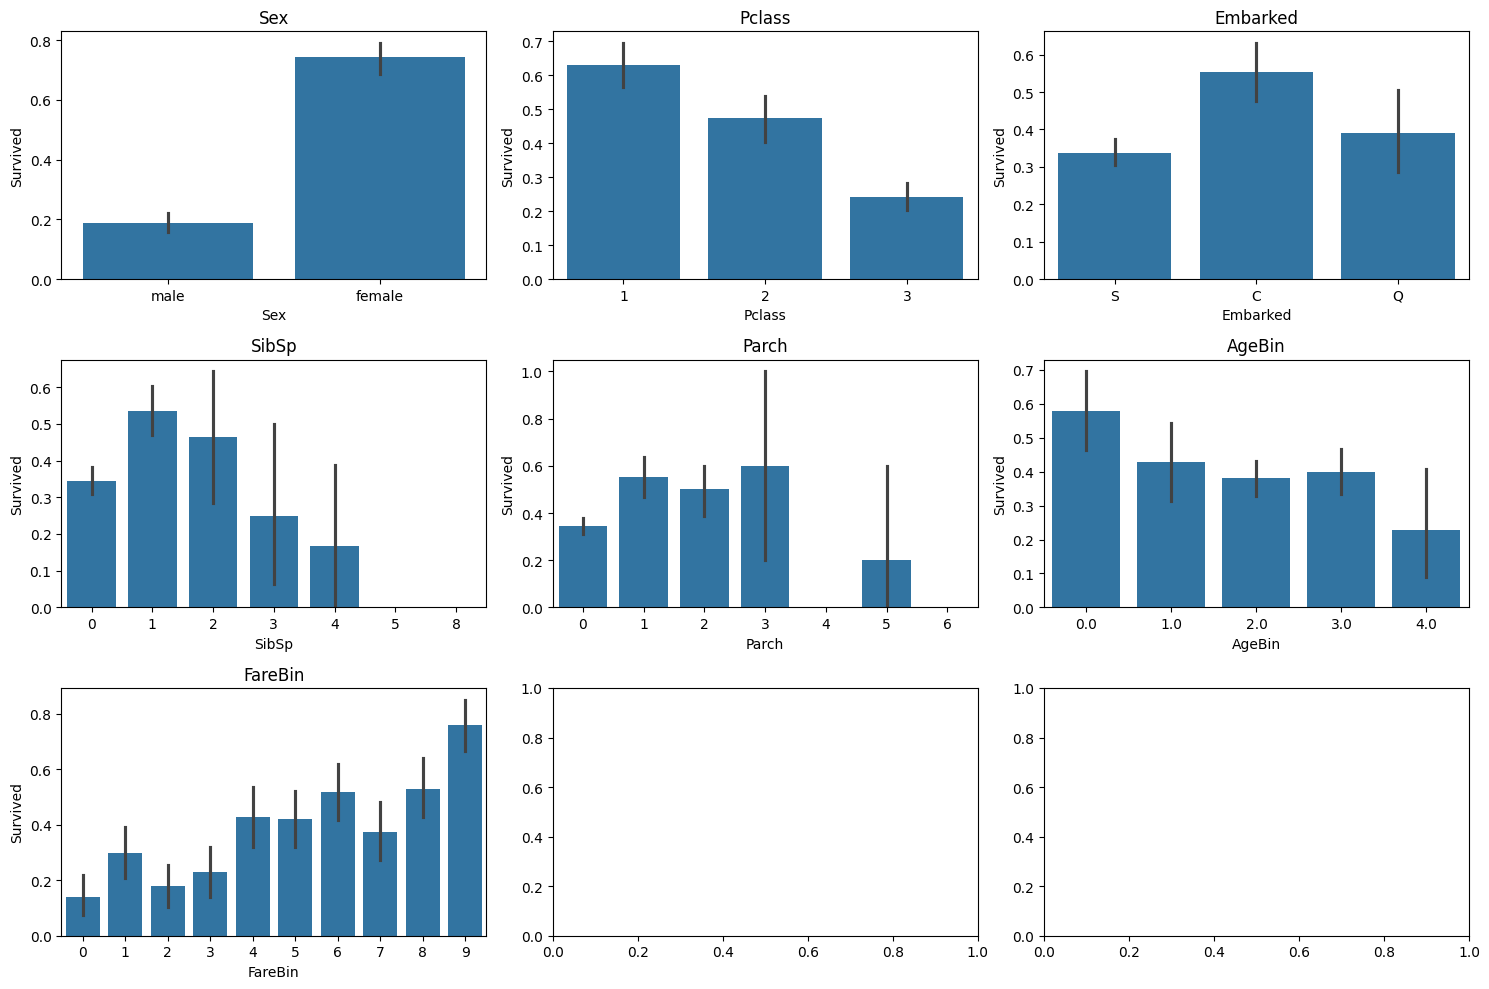

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_check_data = train_data.copy()

feature_check_data["Fare"] = feature_check_data["Fare"].fillna(
    feature_check_data["Fare"].median()
)
feature_check_data["FareLog"] = np.log1p(feature_check_data["Fare"])
feature_check_data["FareBin"] = pd.qcut(
    feature_check_data["FareLog"],
    q=10,
    labels=False
)


bins = [0, 12, 18, 35, 60, 100]
feature_check_data["AgeBin"] = pd.cut(feature_check_data["Age"], bins=bins, labels=False)

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

sns.barplot(x="Sex", y="Survived", data=feature_check_data, ax=axes[0,0])
axes[0, 0].set_title("Sex")

sns.barplot(x="Pclass", y="Survived", data=feature_check_data, ax=axes[0,1])
axes[0, 1].set_title("Pclass")

sns.barplot(x="Embarked", y="Survived", data=feature_check_data, ax=axes[0,2])
axes[0, 2].set_title("Embarked")

sns.barplot(x="SibSp", y="Survived", data=feature_check_data, ax=axes[1,0])
axes[1, 0].set_title("SibSp")

sns.barplot(x="Parch", y="Survived", data=feature_check_data, ax=axes[1,1])
axes[1, 1].set_title("Parch")

sns.barplot(x="AgeBin", y="Survived", data=feature_check_data, ax=axes[1,2])
axes[1, 2].set_title("AgeBin")

sns.barplot(x="FareBin", y="Survived", data=feature_check_data, ax=axes[2,0])
axes[2, 0].set_title("FareBin")

plt.tight_layout()
plt.show()

In [7]:
# Calculating corr
corr = feature_check_data.corr(numeric_only=True)
print(corr)

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   
FareLog        -0.007425  0.329862 -0.661022  0.116495  0.318528  0.332186   
FareBin        -0.010714  0.323875 -0.698107  0.108851  0.357610  0.371574   
AgeBin          0.019037 -0.105213 -0.319811  0.916620 -0.388895 -0.233650   

                 Fare   FareLog   FareBin    AgeBin  
PassengerId  0.012658 -0.007425 -0.010714  0.019037  
Survived     0.257307  0.329862  

# Checking paired combinations

In [8]:
import itertools

features = ["Sex", "Pclass", "AgeBin", "FareBin", "SibSp", "Parch", "Embarked"]

pairs = list(itertools.combinations(features, 2))
print(pairs[:10])


[('Sex', 'Pclass'), ('Sex', 'AgeBin'), ('Sex', 'FareBin'), ('Sex', 'SibSp'), ('Sex', 'Parch'), ('Sex', 'Embarked'), ('Pclass', 'AgeBin'), ('Pclass', 'FareBin'), ('Pclass', 'SibSp'), ('Pclass', 'Parch')]


In [9]:
paired_features = []

for a, b in pairs:
    col=f"{a}_{b}"
    feature_check_data[f"{a}_{b}"] = feature_check_data[a].astype('category').cat.codes * feature_check_data[b].astype('category').cat.codes    
    paired_features.append(col)

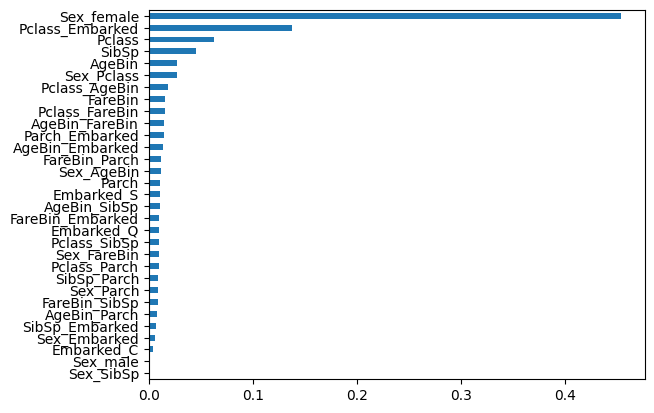

In [10]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

X = feature_check_data[features + paired_features]
y = feature_check_data["Survived"]

X = pd.get_dummies(X)  # encode categories

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05)
model.fit(X_train, y_train)

importances = model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
feat_imp.sort_values().plot(kind="barh")
plt.show()

# Based on feature checking, select features and adding missing values

**Filling missing value**

In [11]:
# Based on plot, we need to select Sex, Pclass, SibSp, Parch, AgeBin, FareBin, Embarked, Pclass_Embarked, Sex_Pclass, Pclass_Parch, FareBin_SibSp, Age_Pclass

full_data = pd.concat([train_data, test_data], sort=False)
score = full_data.isnull().sum()
print("full missing left:", score)
# We need to add missing values Age. Cabin has missing value but it was not selected as feature
# full missing left: 
# PassengerId       0
# Survived        418
# Pclass            0
# Name              0
# Sex               0
# Age             263
# SibSp             0
# Parch             0
# Ticket            0
# Fare              1
# Cabin          1014
# Embarked          2
# dtype: int64

full_data["Age"] = full_data["Age"].fillna(
    full_data.groupby(["Sex", "Pclass", "SibSp", "Parch"])["Age"].transform("median")
)
score = full_data.isnull().sum()["Age"]
print("age missing left:", score)

full_data["Age"] = full_data["Age"].fillna(
    full_data["Age"].median()
)
score = full_data.isnull().sum()["Age"]
print("age missing left:", score)

full_data["Embarked"] = full_data["Embarked"].fillna(
    full_data["Embarked"].mode()[0]
)
full_data["Fare"] = full_data["Fare"].fillna(
    full_data["Fare"].median()
)

#final check
score = full_data.isnull().sum()
print("full missing left:", score)

full missing left: PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64
age missing left: 6
age missing left: 0
full missing left: PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          0
dtype: int64


In [12]:
# Based on plot, we need to select Sex, Pclass, SibSp, Parch, AgeBin, FareBin, Embarked, Pclass_Embarked, Sex_Pclass, Pclass_Parch, FareBin_SibSp, Age_Pclass
# Conver gender to number

# [
#     "Sex",
#     "Pclass",
#     "FareBin",
#     "AgeBin",
#     "Embarked",
#     "Sex_Pclass",
#     "Title",
#     "FamilySize",
#     "IsAlone"
# ]

from sklearn.preprocessing import LabelEncoder

# Select basic features 
features=["Sex", "Pclass", "AgeBin", "FareBin", "Embarked_S", "Embarked_Q", "Embarked_C", "Title", "FamilySize", "IsAlone"]

full_data["Sex"] = full_data["Sex"].map({
    "male": 0,
    "female": 1
})

full_data["Title"] = full_data["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
rare_titles = ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"]
full_data["Title"] = full_data["Title"].replace(rare_titles, "Rare")

full_data["FamilySize"] = full_data["SibSp"] + full_data["Parch"] + 1

full_data["IsAlone"] = (full_data["FamilySize"] == 1).astype(int)

full_data = pd.get_dummies(full_data, columns=["Embarked"])

bins = [0, 12, 18, 35, 60, 100]
full_data["AgeBin"] = pd.cut(full_data["Age"], bins=bins, labels=False)

full_data["FareLog"] = np.log1p(full_data["Fare"])
full_data["FareBin"] = pd.qcut(
    full_data["FareLog"],
    q=10,
    labels=False
)

# Sex_Pclass, Pclass_Parch, FareBin_SibSp, Age_Pclass
col="Sex_Pclass"
full_data["Sex_Pclass"] = full_data["Sex"].astype('category').cat.codes * full_data["Pclass"].astype('category').cat.codes    
features.append("Sex_Pclass")

# col="Pclass_Parch"
# full_data["Pclass_Parch"] = full_data["Parch"].astype('category').cat.codes * full_data["Pclass"].astype('category').cat.codes    
# features.append("Pclass_Parch")

# col="FareBin_SibSp"
# full_data["FareBin_SibSp"] = full_data["FareBin"].astype('category').cat.codes * full_data["SibSp"].astype('category').cat.codes    
# features.append("FareBin_SibSp")

cat_cols = [
    "Title",
    "Sex_Pclass",
    # "Pclass_Parch",
    # "FareBin_SibSp"
]

for col in cat_cols:
    full_data[col] = LabelEncoder().fit_transform(full_data[col].astype(str))

# Training Model

In [13]:
# Training
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
import numpy as np

train_data = full_data[full_data["Survived"].notnull()]
test_data  = full_data[full_data["Survived"].isnull()]
X = train_data[features]
y = train_data["Survived"]

model = XGBClassifier(
    n_estimators=1000,          # allow more trees
    learning_rate=0.02,         # smaller = better
    max_depth=3,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    eval_metric="logloss",
    random_state=42
)


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train_idx, val_idx in kf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model.fit(
        X_train, y_train
    )

    preds = model.predict(X_val)
    scores.append(accuracy_score(y_val, preds))

print("Mean accuracy:", np.mean(scores))

Mean accuracy: 0.8305191136777352


In [14]:
X_test_final = test_data[features]

y_pred = model.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f"Validation Accuracy: {accuracy:.4f}")

predictions = model.predict(X_test_final)

output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Validation Accuracy: 0.8519
Your submission was successfully saved!
